# *******Lisa - Body Tracking Analysis*******

Pipeline for body-tracking (BT) data, mirroring the structure of the Rezvan eye-tracking notebook.

**Inputs:** the four `Johanna_BT_Data_Condition{0,1,2,3}_2026-04-29.csv` files, combined.

**Trackers:** `RightFoot`, `LeftFoot`, `Waist`, `LeftHand`, `RightHand` (5 devices, each with `pos_x/y/z` and `rot_x/y/z/w`).

**Validity rule:** a sample is invalid for a given tracker if its position `(x, y, z) == (0, 0, 0)` (mistracking) or any value is non-finite. Validity is evaluated **independently per tracker**.

**Time:** uses `raw_timestamp` in **milliseconds** (no nanosecond conversion as in the eye-tracking notebook).

**Skipped (vs reference):** angular velocity, median smoothing, velocity categorization, fixation stability.

# Libraries

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt

# Data Path and Loading

Load all 4 Johanna BT files (Condition 0-3) and concatenate them into a single DataFrame.

In [2]:
DATA_DIR = Path("../Other_than_in_project_files/BT_Data")

csv_files = sorted(DATA_DIR.glob("Johanna_BT_Data_Condition*_2026-04-29.csv"))
print("Files found:")
for fp in csv_files:
    print("  ", fp.name)

frames = []
for fp in csv_files:
    d = pd.read_csv(fp, low_memory=False)
    d["participant_id"] = fp.name.split("_")[0]
    d["source_file"] = fp.name
    frames.append(d)

df = pd.concat(frames, axis=0, ignore_index=True)
print("\nCombined shape:", df.shape)
print("Rows per source file:")
print(df["source_file"].value_counts().sort_index())

Files found:
   Johanna_BT_Data_Condition0_2026-04-29.csv
   Johanna_BT_Data_Condition1_2026-04-29.csv
   Johanna_BT_Data_Condition2_2026-04-29.csv
   Johanna_BT_Data_Condition3_2026-04-29.csv

Combined shape: (325115, 65)
Rows per source file:
source_file
Johanna_BT_Data_Condition0_2026-04-29.csv     43138
Johanna_BT_Data_Condition1_2026-04-29.csv     59606
Johanna_BT_Data_Condition2_2026-04-29.csv    126511
Johanna_BT_Data_Condition3_2026-04-29.csv     95860
Name: count, dtype: int64


In [5]:
TRACKERS = ["RightFoot", "LeftFoot", "Waist", "LeftHand", "RightHand"]

POS_COLS = {T: [f"{T}_pos_x", f"{T}_pos_y", f"{T}_pos_z"] for T in TRACKERS}
ROT_COLS = {T: [f"{T}_rot_x", f"{T}_rot_y", f"{T}_rot_z", f"{T}_rot_w"] for T in TRACKERS}

df.head(3)

,raw_timestamp,relative_to_unix_epoch_timestamp,RightFoot_pos_x,RightFoot_pos_y,RightFoot_pos_z,RightFoot_rot_x,RightFoot_rot_y,RightFoot_rot_z,RightFoot_rot_w,LeftFoot_pos_x,...,RightGrab_obj_rot_x,RightGrab_obj_rot_y,RightGrab_obj_rot_z,RightGrab_obj_rot_w,model_name,model_rot_deg,LeftFootArea,RightFootArea,participant_id,source_file
0,1777459547929,133.9991,0.341898,0.088421,-1.140437,0.859899,-0.030480,-0.141585,-0.489488,0.819511,...,0.0,0.0,0.0,1.0,NaN,0,Work,Work,Johanna,Johanna_BT_Data_Condition0_2026-04-29.csv
1,1777459547948,134.0206,0.341979,0.088441,-1.140308,0.859988,-0.030503,-0.141658,-0.489310,0.819488,...,0.0,0.0,0.0,1.0,NaN,0,Work,Work,Johanna,Johanna_BT_Data_Condition0_2026-04-29.csv
2,1777459547959,134.0317,0.342040,0.088393,-1.140285,0.860010,-0.030493,-0.141654,-0.489272,0.819609,...,0.0,0.0,0.0,1.0,NaN,0,Work,Work,Johanna,Johanna_BT_Data_Condition0_2026-04-29.csv


# Estimate Sampling Rate

`raw_timestamp` is in **milliseconds**, so the sampling rate is `1000 / median(dt_ms)`.

In [6]:
t = pd.to_numeric(df["raw_timestamp"], errors="coerce")
dt_ms = t.diff().dropna()

median_dt_ms = dt_ms.median()
sampling_rate_hz = 1000.0 / median_dt_ms

print(f"Estimated sampling rate: {sampling_rate_hz:.2f} Hz")
print(f"Median sample interval: {median_dt_ms:.3f} ms")

# distribution of dt within each file (ignoring file boundaries)
print("\nSample interval (ms) distribution:")
print(dt_ms.describe())

Estimated sampling rate: 90.91 Hz
Median sample interval: 11.000 ms

Sample interval (ms) distribution:
count    325114.000000
mean         11.257873
std           4.515139
min           3.000000
25%          11.000000
50%          11.000000
75%          12.000000
max         583.000000
Name: raw_timestamp, dtype: float64


# Preprocessing Function

Drop rows where `model_name` is missing, the literal string `"None"`, or contains `"TM"` (training models).

In [7]:
def cleaning_function(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess body-tracking data for analysis.

    Steps:
        - drop rows where model_name is NaN
        - drop rows where model_name is the literal string 'None'
        - drop rows where model_name contains 'TM' (training models)
    """

    df = df.copy()

    name = df["model_name"].astype("string")

    mask = (
        name.notna() &
        (name.str.lower() != "none") &
        (~name.str.contains("TM", na=False))
    )

    df = df.loc[mask].copy()
    return df

df_clean = cleaning_function(df)
print("Before cleaning:", df.shape)
print("After cleaning: ", df_clean.shape)
print("\nUnique model_name (after cleaning):")
print(df_clean["model_name"].value_counts().head(20))

Before cleaning: (325115, 65)
After cleaning:  (177728, 65)

Unique model_name (after cleaning):
model_name
C3M2A    20916
C3M4A    20737
C3M3F    20386
C2M2A    15764
C3M5F    14536
C2M6A    12104
C2M1F    10195
C1M5F     9214
C3M6A     8743
C2M4A     7784
C3M1F     7305
C2M3F     7123
C1M4A     5627
C1M6A     5457
C2M5F     4102
C1M3F     2719
C1M1F     2571
C1M2A     2445
Name: count, dtype: int64


# Time Function

Add a `time_ms` column relative to the **first sample of each `model_name`**, after sorting by `condition_number`, `trial_number`, `raw_timestamp`. Since `raw_timestamp` is already in ms, no unit conversion is needed.

In [8]:
def add_time_per_model(df, time_col: str = "raw_timestamp"):
    """
    Add `time_ms` per model_name, respecting experiment order.

    Sorting: condition_number -> trial_number -> time_col

    Add 'dt_ms' duartion between timestemps

    Assumes:
        - time_col is in milliseconds
        - df contains: model_name, condition_number, trial_number
    """
    df = df.copy()
    df = df.sort_values(["condition_number", "trial_number", time_col])

    t0 = df.groupby("model_name")[time_col].transform("first")
    df["time_ms"] = (df[time_col] - t0).astype(float)
    return df

df_clean = add_time_per_model(df_clean, time_col="raw_timestamp")

seg = (
    df_clean[(df_clean["condition_number"] == df_clean["condition_number"].iloc[0]) &
             (df_clean["trial_number"] == df_clean["trial_number"].iloc[0])]
    .sort_values("time_ms")
    .reset_index(drop=True)
)
seg["dt_ms"] = seg["time_ms"].diff()
print(seg[["raw_timestamp", "time_ms", "dt_ms", "condition_number", "trial_number", "model_name"]].head(15).to_string())

    raw_timestamp  time_ms  dt_ms  condition_number  trial_number model_name
0   1777460162837      0.0    NaN                 1             1      C2M5F
1   1777460162840      3.0    3.0                 1             1      C2M5F
2   1777460162851     14.0   11.0                 1             1      C2M5F
3   1777460162861     24.0   10.0                 1             1      C2M5F
4   1777460162874     37.0   13.0                 1             1      C2M5F
5   1777460162883     46.0    9.0                 1             1      C2M5F
6   1777460162894     57.0   11.0                 1             1      C2M5F
7   1777460162905     68.0   11.0                 1             1      C2M5F
8   1777460162917     80.0   12.0                 1             1      C2M5F
9   1777460162927     90.0   10.0                 1             1      C2M5F
10  1777460162938    101.0   11.0                 1             1      C2M5F
11  1777460162955    118.0   17.0                 1             1      C2M5F

# Define Valid Samples and Interpolation

**Validity rule (per tracker, per row):** invalid if `(pos_x, pos_y, pos_z) == (0, 0, 0)` (mistracking) or any of them is non-finite.

Each tracker is processed independently:
1. Find contiguous runs of bad samples on that tracker.
2. Pad each run by 2 samples on both sides (to remove edge artifacts), then merge overlaps.
3. If the padded run is bracketed by valid samples on the left and right, linearly interpolate `pos_x`, `pos_y`, `pos_z` against `time_ms`.
4. Output columns per tracker: `clean_<T>_pos_x/y/z`, `bad_sample_<T>`, `is_interpolated_<T>`.

Quaternion rotations (`rot_x/y/z/w`) are **not** interpolated (would require slerp); rows where the corresponding tracker was interpolated should be treated as having unreliable rotation.

In [9]:
def good_position(xyz: np.ndarray) -> np.ndarray:
    """
    Returns a boolean mask: True for valid samples.
    Invalid if (x, y, z) == (0, 0, 0) or any value is non-finite.
    """
    xyz = np.asarray(xyz, dtype=float)
    finite = np.isfinite(xyz).all(axis=1)
    is_zero = (xyz == 0).all(axis=1)
    return finite & ~is_zero


def find_runs(mask: np.ndarray):
    """Return list of (start, end) inclusive index pairs for True-runs in mask."""
    mask = np.asarray(mask, dtype=bool)
    idx = np.flatnonzero(mask)
    if len(idx) == 0:
        return []

    runs = []
    start = prev = idx[0]
    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            runs.append((start, prev))
            start = prev = k
    runs.append((start, prev))
    return runs


def expand_runs(runs, n, pad=2):
    """Expand each run by `pad` samples on both sides, then merge overlaps."""
    if len(runs) == 0:
        return []

    expanded = []
    for a, b in runs:
        aa = max(0, a - pad)
        bb = min(n - 1, b + pad)
        expanded.append((aa, bb))

    expanded.sort()
    merged = [expanded[0]]
    for a, b in expanded[1:]:
        prev_a, prev_b = merged[-1]
        if a <= prev_b + 1:
            merged[-1] = (prev_a, max(prev_b, b))
        else:
            merged.append((a, b))
    return merged

In [10]:
def interpolate_tracker_segment(
    sub: pd.DataFrame,
    tracker: str,
    pad: int = 2,
) -> pd.DataFrame:
    """
    Interpolate one tracker's pos_x/y/z within a (condition, trial) segment.
    Adds: clean_<T>_pos_x/y/z, bad_sample_<T>, is_interpolated_<T>.
    """
    sub = sub.sort_values("time_ms").copy()
    t = sub["time_ms"].to_numpy(dtype=float)

    pos_cols = POS_COLS[tracker]
    xyz = np.column_stack([
        pd.to_numeric(sub[c], errors="coerce").to_numpy(dtype=float)
        for c in pos_cols
    ])

    good = good_position(xyz)
    bad = ~good
    bad_runs = find_runs(bad)

    n = len(sub)
    is_interpolated = np.zeros(n, dtype=bool)
    clean = xyz.copy()

    buffered_runs = expand_runs(bad_runs, n=n, pad=pad)

    # set buffered regions to NaN before interpolation
    for a, b in buffered_runs:
        clean[a:b + 1, :] = np.nan

    for a, b in buffered_runs:
        left = a - 1
        right = b + 1

        bracketed = (
            left >= 0 and
            right < n and
            np.all(np.isfinite(xyz[left])) and not (xyz[left] == 0).all() and
            np.all(np.isfinite(xyz[right])) and not (xyz[right] == 0).all()
        )

        if bracketed:
            for dim in range(3):
                clean[a:b + 1, dim] = np.interp(
                    t[a:b + 1],
                    [t[left], t[right]],
                    [xyz[left, dim], xyz[right, dim]],
                )
            is_interpolated[a:b + 1] = True

    sub[f"bad_sample_{tracker}"] = bad
    sub[f"is_interpolated_{tracker}"] = is_interpolated
    for j, c in enumerate(pos_cols):
        sub[f"clean_{c}"] = clean[:, j]

    return sub


def interpolate_all_segments(df: pd.DataFrame, pad: int = 2) -> pd.DataFrame:
    """
    For each (condition, trial) group, interpolate every tracker independently.
    """
    out = []
    for (cond, trial), sub in df.groupby(["condition_number", "trial_number"], sort=True):
        sub = sub.sort_values("time_ms").copy()
        for T in TRACKERS:
            sub = interpolate_tracker_segment(sub, tracker=T, pad=pad)
        sub["segment_label"] = f"C{int(cond)}_T{int(trial)}"
        out.append(sub)

    return (
        pd.concat(out, axis=0)
        .sort_values(["condition_number", "trial_number", "time_ms"])
        .reset_index(drop=True)
    )

In [11]:
df_clean = interpolate_all_segments(df_clean, pad=2)

added_cols = [c for c in df_clean.columns if c.startswith("clean_") or c.startswith("is_interpolated_") or c.startswith("bad_sample_")]
print(f"Added {len(added_cols)} columns:")
for c in added_cols:
    print("  ", c)

Added 25 columns:
   bad_sample_RightFoot
   is_interpolated_RightFoot
   clean_RightFoot_pos_x
   clean_RightFoot_pos_y
   clean_RightFoot_pos_z
   bad_sample_LeftFoot
   is_interpolated_LeftFoot
   clean_LeftFoot_pos_x
   clean_LeftFoot_pos_y
   clean_LeftFoot_pos_z
   bad_sample_Waist
   is_interpolated_Waist
   clean_Waist_pos_x
   clean_Waist_pos_y
   clean_Waist_pos_z
   bad_sample_LeftHand
   is_interpolated_LeftHand
   clean_LeftHand_pos_x
   clean_LeftHand_pos_y
   clean_LeftHand_pos_z
   bad_sample_RightHand
   is_interpolated_RightHand
   clean_RightHand_pos_x
   clean_RightHand_pos_y
   clean_RightHand_pos_z


# Sorting

In [12]:
df_clean = (
    df_clean
    .sort_values(["condition_number", "trial_number", "raw_timestamp"])
    .reset_index(drop=True)
)
df_clean.head(3)

,raw_timestamp,relative_to_unix_epoch_timestamp,RightFoot_pos_x,RightFoot_pos_y,RightFoot_pos_z,RightFoot_rot_x,RightFoot_rot_y,RightFoot_rot_z,RightFoot_rot_w,LeftFoot_pos_x,...,is_interpolated_LeftHand,clean_LeftHand_pos_x,clean_LeftHand_pos_y,clean_LeftHand_pos_z,bad_sample_RightHand,is_interpolated_RightHand,clean_RightHand_pos_x,clean_RightHand_pos_y,clean_RightHand_pos_z,segment_label
0,1777460162837,748.7068,0.288992,0.104968,-0.150986,0.701207,0.343197,0.525002,-0.338965,0.272880,...,False,0.773735,1.068906,0.165082,False,False,0.766491,1.076719,-0.158100,C1_T1
1,1777460162840,748.7115,0.288998,0.104973,-0.150982,0.701198,0.343183,0.525056,-0.338913,0.272876,...,False,0.773772,1.068841,0.165080,False,False,0.766439,1.076770,-0.158230,C1_T1
2,1777460162851,748.7213,0.289008,0.104984,-0.150976,0.701199,0.343154,0.525061,-0.338934,0.272952,...,False,0.773838,1.068742,0.165075,False,False,0.766544,1.076789,-0.158329,C1_T1


# Interpolation Check

Plot raw vs cleaned `pos_x/y/z` around the first interpolated run for each tracker (when one exists).

RightFoot: no interpolated samples - skipping plot
LeftFoot: plotting first interpolated run in C2_T1 (samples 4736-4805)


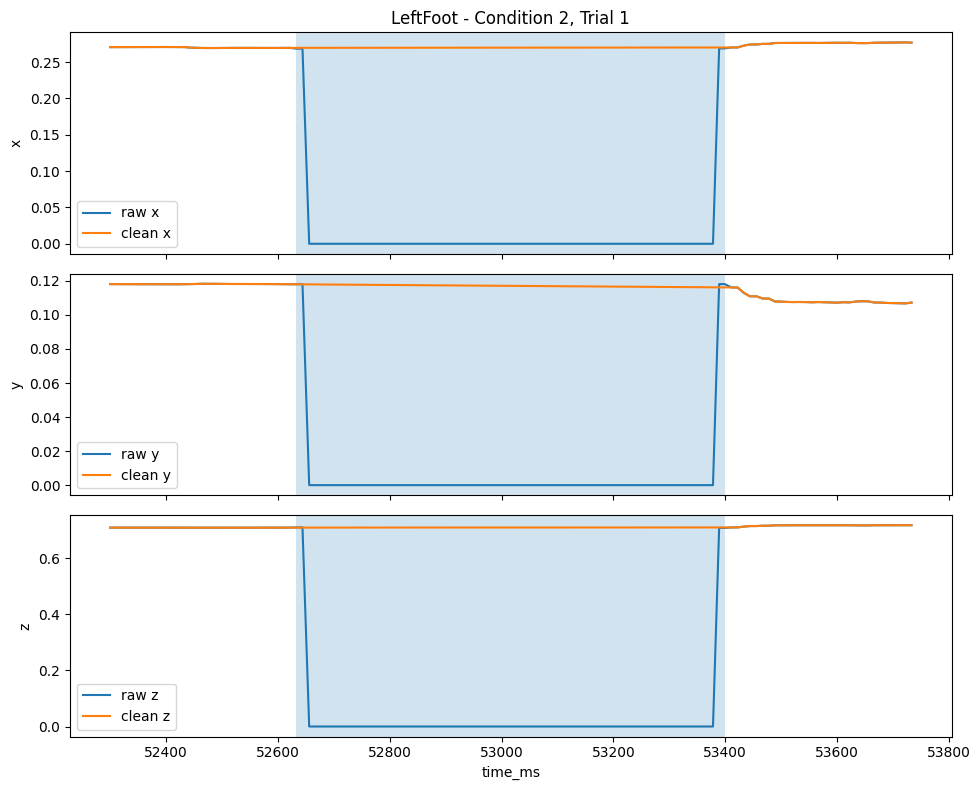

Waist: plotting first interpolated run in C1_T1 (samples 392-396)


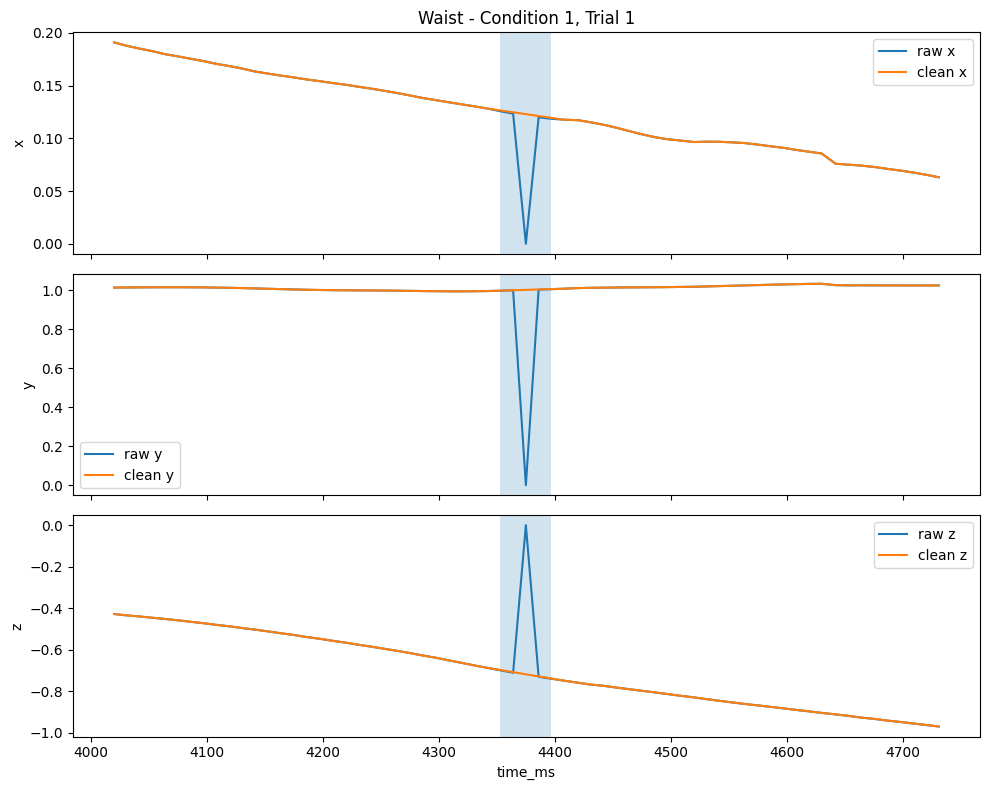

LeftHand: plotting first interpolated run in C1_T6 (samples 4173-4179)


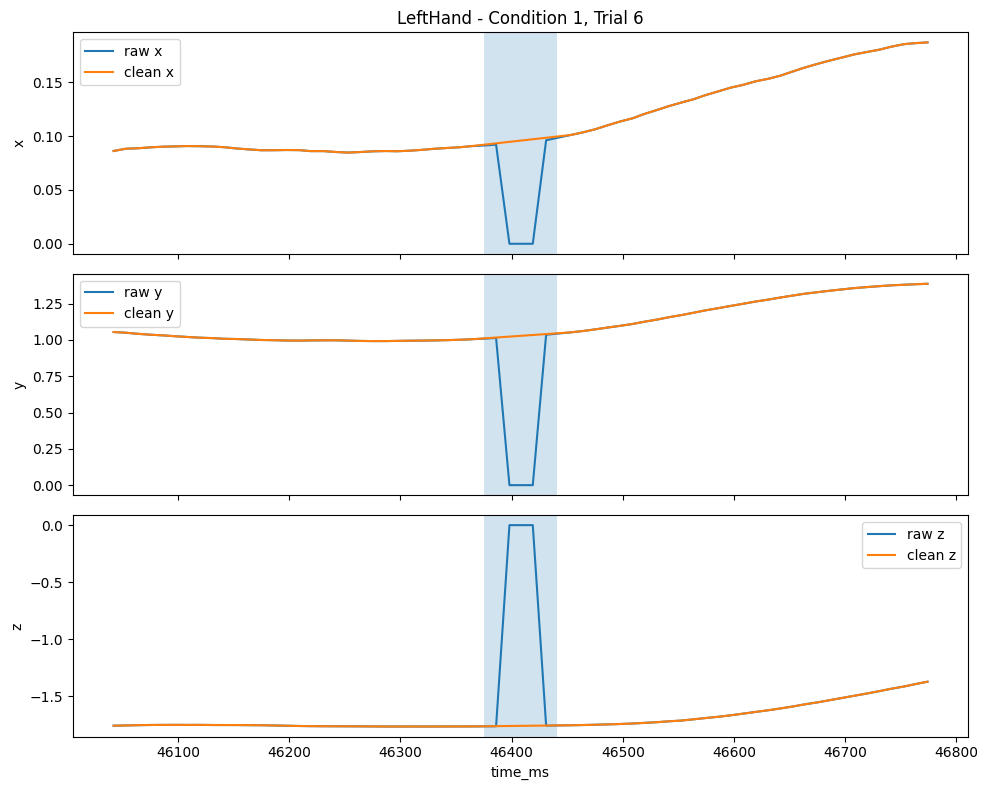

RightHand: plotting first interpolated run in C1_T6 (samples 2542-2552)


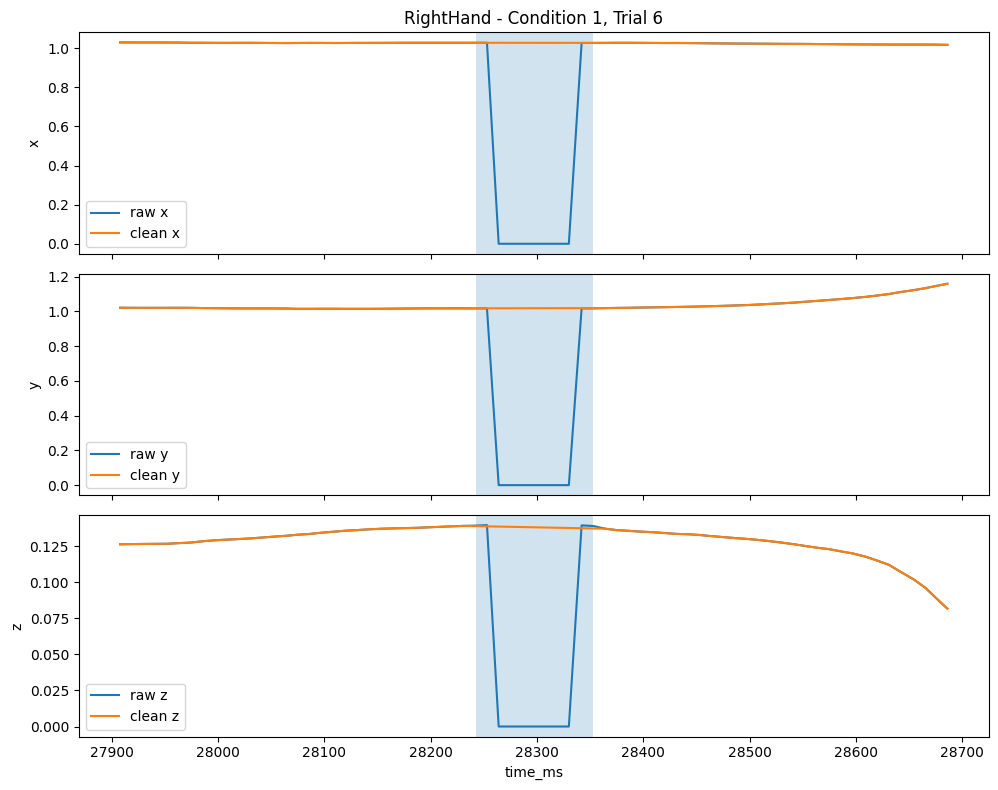

In [13]:
def plot_interpolation_xyz(
    df_segment: pd.DataFrame,
    tracker: str,
    center_start: int,
    center_end: int,
    pad: int = 30,
):
    """
    Plot raw vs cleaned x/y/z around one interpolated run for a given tracker.
    """
    sub = df_segment.sort_values("time_ms").reset_index(drop=True)
    a = max(0, center_start - pad)
    b = min(len(sub) - 1, center_end + pad)
    win = sub.iloc[a:b + 1].copy()

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for ax, comp in zip(axes, ["x", "y", "z"]):
        raw_col = f"{tracker}_pos_{comp}"
        clean_col = f"clean_{tracker}_pos_{comp}"

        ax.plot(win["time_ms"], win[raw_col], label=f"raw {comp}")
        ax.plot(win["time_ms"], win[clean_col], label=f"clean {comp}")

        interp_mask = win[f"is_interpolated_{tracker}"].fillna(False).to_numpy(dtype=bool)
        if interp_mask.any():
            interp_times = win.loc[interp_mask, "time_ms"]
            ax.axvspan(interp_times.min(), interp_times.max(), alpha=0.2)

        ax.set_ylabel(f"{comp}")
        ax.legend(loc="best")

    cond = win["condition_number"].iloc[0]
    trial = win["trial_number"].iloc[0]
    axes[0].set_title(f"{tracker} - Condition {cond}, Trial {trial}")
    axes[-1].set_xlabel("time_ms")
    plt.tight_layout()
    plt.show()


for T in TRACKERS:
    interp_col = f"is_interpolated_{T}"
    if interp_col not in df_clean.columns or not df_clean[interp_col].any():
        print(f"{T}: no interpolated samples - skipping plot")
        continue

    found = False
    for (cond, trial), sub in df_clean.groupby(["condition_number", "trial_number"], sort=True):
        sub = sub.sort_values("time_ms").reset_index(drop=True)
        runs = find_runs(sub[interp_col].fillna(False).to_numpy())
        if runs:
            a, b = runs[0]
            print(f"{T}: plotting first interpolated run in C{int(cond)}_T{int(trial)} (samples {a}-{b})")
            plot_interpolation_xyz(sub, tracker=T, center_start=a, center_end=b, pad=30)
            found = True
            break
    if not found:
        print(f"{T}: no interpolated runs found")

# Descriptive Statistics

## Percentage of Interpolation (per tracker)

Important: with multiple devices, we want to know how much of the data was interpolated **for each tracker** separately.

In [15]:
n_total = len(df_clean)
rows = []
for T in TRACKERS:
    n_bad = int(df_clean[f"bad_sample_{T}"].sum())
    n_interp = int(df_clean[f"is_interpolated_{T}"].sum())
    rows.append({
        "tracker": T,
        "n_total": n_total,
        "n_bad_raw": n_bad,
        "percent_bad_raw": 100 * n_bad / n_total,
        "n_interpolated": n_interp,
        "percent_interpolated": 100 * n_interp / n_total,
    })

interp_pct = pd.DataFrame(rows)
print("=== Interpolation stats per tracker (FULL dataset) ===")
print(interp_pct.to_string(index=False))

=== Interpolation stats per tracker (FULL dataset) ===
  tracker  n_total  n_bad_raw  percent_bad_raw  n_interpolated  percent_interpolated
RightFoot   177728          0         0.000000               0              0.000000
 LeftFoot   177728        108         0.060767             132              0.074271
    Waist   177728      12369         6.959511           13041              7.337617
 LeftHand   177728        377         0.212122             541              0.304398
RightHand   177728         30         0.016880              62              0.034885


In [18]:
# Per-condition breakdown of interpolation %
per_cond_rows = []
for (cond,), sub in df_clean.groupby(["condition_number"], sort=True):
    n_t = len(sub)
    row = {"condition_number": int(cond), "n_total": n_t}
    for T in TRACKERS:
        n_i = int(sub[f"is_interpolated_{T}"].sum())
        row[f"{T}_percent"] = round(100 * n_i / n_t, 2) if n_t else np.nan
    per_cond_rows.append(row)

per_cond = pd.DataFrame(per_cond_rows)
print("=== Interpolation % per condition x tracker ===")
print(per_cond.to_string(index=False))

=== Interpolation % per condition x tracker ===
 condition_number  n_total  RightFoot_percent  LeftFoot_percent  Waist_percent  LeftHand_percent  RightHand_percent
                1    33098                0.0              0.00           2.49              0.17               0.07
                2    72387                0.0              0.18          14.95              0.51               0.04
                3    72243                0.0              0.00           1.94              0.16               0.01


## Interpolated Segments Durations (per tracker)

For each tracker, find contiguous runs of `is_interpolated_<T> == True` (within each `(condition, trial)` group) and report length and duration distributions.

In [19]:
def find_true_runs(x):
    """Return list of (start_idx, end_idx) inclusive for runs of True in x."""
    runs = []
    start = None
    for i, val in enumerate(x):
        if val and start is None:
            start = i
        elif not val and start is not None:
            runs.append((start, i - 1))
            start = None
    if start is not None:
        runs.append((start, len(x) - 1))
    return runs


df_clean = df_clean.sort_values(
    ["condition_number", "trial_number", "raw_timestamp"]
).reset_index(drop=True)

all_segments = {}
for T in TRACKERS:
    seg_rows = []
    interp_col = f"is_interpolated_{T}"
    for (cond, trial), sub in df_clean.groupby(["condition_number", "trial_number"]):
        sub = sub.reset_index(drop=True)
        runs = find_true_runs(sub[interp_col].fillna(False).to_numpy())
        for start, end in runs:
            n_samples = end - start + 1
            start_t = sub.loc[start, "raw_timestamp"]
            end_t = sub.loc[end, "raw_timestamp"]
            duration_ms = float(end_t - start_t)
            seg_rows.append({
                "tracker": T,
                "condition_number": cond,
                "trial_number": trial,
                "start_idx": start,
                "end_idx": end,
                "n_samples": n_samples,
                "start_time": start_t,
                "end_time": end_t,
                "duration_ms": duration_ms,
            })
    all_segments[T] = pd.DataFrame(seg_rows)

for T in TRACKERS:
    seg = all_segments[T]
    print(f"\n=== {T} - interpolated segments ===")
    print(f"Number of interpolated segments: {len(seg)}")
    if len(seg) == 0:
        continue
    print("Segment length in samples:")
    print(seg["n_samples"].describe().to_string())
    print("Segment duration in ms:")
    print(seg["duration_ms"].describe().to_string())


=== RightFoot - interpolated segments ===
Number of interpolated segments: 0

=== LeftFoot - interpolated segments ===
Number of interpolated segments: 6
Segment length in samples:
count     6.000000
mean     22.000000
std      24.543838
min       5.000000
25%       8.000000
50%      12.500000
75%      22.250000
max      70.000000
Segment duration in ms:
count      6.000000
mean     233.166667
std      272.353753
min       45.000000
25%       78.000000
50%      127.500000
75%      235.500000
max      766.000000

=== Waist - interpolated segments ===
Number of interpolated segments: 168
Segment length in samples:
count     168.000000
mean       77.625000
std       142.822686
min         5.000000
25%         9.750000
50%        25.000000
75%        75.250000
max      1010.000000
Segment duration in ms:
count      168.000000
mean       851.583333
std       1587.104913
min         43.000000
25%         98.250000
50%        267.000000
75%        825.000000
max      11212.000000

=== LeftHa

In [20]:
# Compact summary across trackers
summary_rows = []
for T in TRACKERS:
    seg = all_segments[T]
    if len(seg) == 0:
        summary_rows.append({
            "tracker": T, "n_segments": 0,
            "median_dur_ms": np.nan, "mean_dur_ms": np.nan,
            "max_dur_ms": np.nan, "total_dur_ms": 0.0,
        })
    else:
        summary_rows.append({
            "tracker": T,
            "n_segments": len(seg),
            "median_dur_ms": seg["duration_ms"].median(),
            "mean_dur_ms": seg["duration_ms"].mean(),
            "max_dur_ms": seg["duration_ms"].max(),
            "total_dur_ms": seg["duration_ms"].sum(),
        })

seg_summary = pd.DataFrame(summary_rows)
print("=== Per-tracker segment summary ===")
print(seg_summary.to_string(index=False))

=== Per-tracker segment summary ===
  tracker  n_segments  median_dur_ms  mean_dur_ms  max_dur_ms  total_dur_ms
RightFoot           0            NaN          NaN         NaN           0.0
 LeftFoot           6          127.5   233.166667       766.0        1399.0
    Waist         168          267.0   851.583333     11212.0      143066.0
 LeftHand          41          101.0   135.463415       478.0        5554.0
RightHand           8           66.0    74.250000       144.0         594.0


## Checking the sampling rate after interpolation

Compute `dt` between consecutive samples within each `(condition, trial)`, and the implied per-row sampling rate. Flag rows where the rate dropped below 80% of the median rate computed earlier.

In [23]:
df_clean["dt"] = df_clean.groupby(
    ["condition_number", "trial_number"]
)["time_ms"].diff()

print("=== dt (ms) describe ===")
print(df_clean["dt"].describe())

=== dt (ms) describe ===
count    177710.000000
mean         11.162596
std           2.952290
min           3.000000
25%          11.000000
50%          11.000000
75%          12.000000
max         310.000000
Name: dt, dtype: float64


In [24]:
# per-row sampling rate (Hz) from dt
df_clean["sampling_rate_hz"] = 1000.0 / df_clean["dt"]

print("=== sampling_rate_hz describe ===")
print(df_clean["sampling_rate_hz"].describe())

# flag low-rate rows: below 80% of the dataset median rate
median_rate = df_clean["sampling_rate_hz"].median()
low_thresh = 0.8 * median_rate
low_rows = df_clean[df_clean["sampling_rate_hz"] < low_thresh]

print(f"\nMedian per-row sampling rate: {median_rate:.2f} Hz")
print(f"Threshold for 'low rate': {low_thresh:.2f} Hz")
print(f"Rows below threshold: {len(low_rows)} / {len(df_clean)} ({100 * len(low_rows) / len(df_clean):.2f}%)")

cols_show = ["raw_timestamp", "time_ms", "dt", "sampling_rate_hz", "condition_number", "trial_number"]
print("\nFirst 20 low-rate rows:")
print(low_rows[cols_show].head(20).to_string())

=== sampling_rate_hz describe ===
count    177710.000000
mean         90.386260
std           6.595320
min           3.225806
25%          83.333333
50%          90.909091
75%          90.909091
max         333.333333
Name: sampling_rate_hz, dtype: float64

Median per-row sampling rate: 90.91 Hz
Threshold for 'low rate': 72.73 Hz
Rows below threshold: 318 / 177728 (0.18%)

First 20 low-rate rows:
      raw_timestamp  time_ms     dt  sampling_rate_hz  condition_number  trial_number
11    1777460162955    118.0   17.0         58.823529                 1             1
547   1777460168914   6077.0   14.0         71.428571                 1             1
1153  1777460175649  12812.0   14.0         71.428571                 1             1
1266  1777460176913  14076.0   22.0         45.454545                 1             1
1277  1777460177034  14197.0   14.0         71.428571                 1             1
2343  1777460188885  26048.0   16.0         62.500000                 1             

In [25]:
# Per-condition sampling-rate summary after interpolation
print("=== Sampling rate (Hz) describe per condition ===")
print(
    df_clean.groupby("condition_number")["sampling_rate_hz"]
    .describe()[["count", "mean", "50%", "min", "max"]]
    .rename(columns={"50%": "median"})
)

=== Sampling rate (Hz) describe per condition ===
                    count       mean     median       min         max
condition_number                                                     
1                 33092.0  90.423024  90.909091  4.672897  333.333333
2                 72381.0  90.375103  90.909091  4.524887  250.000000
3                 72237.0  90.380599  90.909091  3.225806  200.000000
